## This notebook provides a few key ideas & functions necessary to further understand how to process MLB pitching data from Statcast. 

## Key Function 1: Generating a General Strikezone - Scaling pitches to the batter's zone. 


# We generate a generic 'Strike Zone', which varies dependent on the batter's height. 
# We scale the pitch data relative to the player-specific strike zone, and create a new visualization of the pitch location, offering a more specific visualization based on the strike zone of each batter, as opposed to a general range. 


## Key Function 2: Finding Discrepancies between assigning "Strike" to a pitch location. 

# We then compare the zones provided by the pitch data to find what are assigned the value of "Strike" 
# We also compare the location of the pitch, with the provided strike zone of the batter to assign values of "Strikes"
# We notice a discrepancy between these 2 values in specific cases, which may lead to faulty data quality. 
# We continue to explore these discpencies using further data from the specific pitches. 

In [1]:
### Importing Libraries

import os
import pandas as pd
import numpy as np
import requests
import json
from typing import Dict, Any, Optional, List, Union
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import seaborn as sns
from sklearn.cluster import KMeans
import pybaseball as bb
import datetime
import time
import concurrent.futures

In [ ]:
# Defining Functions to Get Pitching Data

# Option 1: Get MLB Stats API data only
# Option 2: Get Statcast data only
# Option 3: Get comprehensive data both datasets

def get_pitcher_stats(player_id: int, season: int) -> Dict[str, Any]:
    """
    Download the pitching statistics for a specific pitcher in a given season using MLB Stats API.
    
    Args:
        player_id (int): The MLB player ID of the pitcher
        season (int): The season year (e.g., 2023)
    
    Returns:
        Dict[str, Any]: Dictionary containing the pitcher's statistics
    """
    # MLB Stats API endpoint for player stats
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}/stats"
    
    # Parameters for the API request - only get pitching stats
    params = {
        "stats": "season",
        "group": "pitching",  # Only request pitching stats
        "season": str(season),
        "sportId": "1",  # MLB is sportId 1
        "hydrate": "metrics"  # Include additional pitching metrics
    }
    
    try:
        # Make the API request
        response = requests.get(url, params=params)
        response.raise_for_status()  # Raise an exception for bad responses
        
        # Check if player is a pitcher
        data = response.json()
        if not data.get('stats') or not any(stat.get('group', {}).get('displayName') == 'pitching' 
                                          for stat in data.get('stats', [])):
            raise ValueError(f"Player {player_id} does not have pitching statistics")
            
        return data
    
    except requests.exceptions.RequestException as e:
        print(f"Error fetching pitching data: {e}")
        return {}
    except ValueError as e:
        print(e)
        return {}

def get_player_info(player_id: int) -> Dict[str, Any]:
    """
    Get basic information about a player.
    
    Args:
        player_id (int): The MLB player ID
    
    Returns:
        Dict[str, Any]: Dictionary containing the player's information
    """
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.json()
    
    except requests.exceptions.RequestException as e:
        print(f"Error fetching player info: {e}")
        return {}

def process_stats(stats_data: Dict[str, Any], category: str) -> Optional[pd.DataFrame]:
    """
    Process the statistics data for a specific category (hitting, pitching, fielding).
    
    Args:
        stats_data (Dict[str, Any]): The statistics data from the API
        category (str): The category of statistics ('hitting', 'pitching', or 'fielding')
    
    Returns:
        Optional[pd.DataFrame]: DataFrame containing the processed statistics, or None if not available
    """
    if not stats_data or 'stats' not in stats_data:
        return None
    
    stats_list = []
    
    # Process all splits and groups to find the category data
    for stat_group in stats_data['stats']:
        group_name = stat_group.get('group', {}).get('displayName', '').lower()
        if group_name == category:
            if 'splits' in stat_group and stat_group['splits']:
                for split in stat_group['splits']:
                    if 'stat' in split:
                        stats_list.append(split['stat'])
    
    if stats_list:
        return pd.DataFrame(stats_list)
    
    return None

def get_all_player_stats(player_id: int, season: int) -> Dict[str, pd.DataFrame]:
    """
    Get all statistics (hitting, pitching, fielding) for a player in a specific season.
    
    Args:
        player_id (int): The MLB player ID
        season (int): The season year
    
    Returns:
        Dict[str, pd.DataFrame]: Dictionary with keys 'hitting', 'pitching', 'fielding' 
                               and corresponding DataFrames as values
    """
    stats_data = get_pitcher_stats(player_id, season)
    player_info = get_player_info(player_id)
    
    result = {}
    
    # Add player basic info
    if player_info and 'people' in player_info and player_info['people']:
        person = player_info['people'][0]
        result['player_info'] = pd.DataFrame([{
            'fullName': person.get('fullName', ''),
            'primaryNumber': person.get('primaryNumber', ''),
            'primaryPosition': person.get('primaryPosition', {}).get('abbreviation', ''),
            'birthDate': person.get('birthDate', ''),
            'currentTeam': person.get('currentTeam', {}).get('name', '') if 'currentTeam' in person else '',
            'height': person.get('height', ''),
            'weight': person.get('weight', '')
        }])
    
    # Process statistics for each category
    for category in ['pitching']:
        df = process_stats(stats_data, category)
        if df is not None:
            result[category] = df
    
    return result

def get_pitcher_statcast(pid: int, year: int) -> pd.DataFrame:
    """
    Get Statcast data for a specific pitcher in a given year.
    
    Args:
        pid (int): The MLB player ID of the pitcher
        year (int): The season year (e.g., 2024)
    
    Returns:
        pd.DataFrame: DataFrame containing the pitcher's Statcast data, or None if no data found/error occurs
    """
    try:
        # Add retry logic
        max_retries = 3
        for attempt in range(max_retries):
            try:
                # Convert year to date range
                start_date = f"{year}-03-01"
                end_date = f"{year}-11-01"
                
                print(f"Fetching Statcast data for pitcher ID {pid} in {year}...")
                
                # Get Statcast data for the pitcher
                df_pitches = bb.statcast_pitcher(start_dt=start_date,
                                       end_dt=end_date,
                                       player_id=pid)
                
                # Add pitcher ID as a column
                if df_pitches is not None and not df_pitches.empty:
                    df_pitches['pitcher_id'] = pid
                    print(f"Successfully retrieved Statcast data for pitcher ID {pid}")
                    return df_pitches
                else:
                    print(f"No Statcast data found for pitcher ID {pid}")
                    return None
                    
            except Exception as e:
                if attempt < max_retries - 1:
                    print(f"Attempt {attempt+1} failed: {e}. Retrying...")
                    time.sleep(2)  # Wait before retry
                else:
                    raise e
                    
    except Exception as e:
        print(f"Error getting Statcast data for pitcher ID {pid}: {e}")
        return None

def display_stats(stats_dict: Dict[str, pd.DataFrame]) -> None:
    """
    Display the statistics in a readable format.
    
    Args:
        stats_dict (Dict[str, pd.DataFrame]): Dictionary of statistics DataFrames
    """
    if 'player_info' in stats_dict:
        info = stats_dict['player_info'].iloc[0]
        print(f"Player: {info['fullName']} (#{info.get('primaryNumber', 'N/A')})")
        print(f"Position: {info.get('primaryPosition', 'N/A')}")
        print(f"Team: {info.get('currentTeam', 'N/A')}")
        print(f"Height: {info.get('height', 'N/A')} | Weight: {info.get('weight', 'N/A')} | DOB: {info.get('birthDate', 'N/A')}")
        print("\n" + "=" * 50 + "\n")
    
    categories = [cat for cat in stats_dict.keys() if cat != 'player_info']
    
    if not categories:
        print("No statistics available for this player in the specified season.")
        return
    
    for category in categories:
        print(f"{category.upper()} STATISTICS:")
        if stats_dict[category].empty:
            print(f"No {category} statistics available.")
        else:
            # Select the most important columns for pitching
            if category == 'pitching':
                columns = ['gamesPlayed', 'gamesStarted', 'inningsPitched', 'wins', 'losses', 'saves', 
                          'era', 'strikeOuts', 'whip', 'hitsPer9Inn', 'homeRunsPer9', 'strikeoutsPer9Inn']
            else:
                columns = stats_dict[category].columns
            
            # Display only columns that exist in the DataFrame
            existing_columns = [col for col in columns if col in stats_dict[category].columns]
            if existing_columns:
                print(stats_dict[category][existing_columns].to_string(index=False))
            else:
                print(stats_dict[category].to_string(index=False))
        
        print("\n" + "=" * 50 + "\n")

def save_stats_to_csv(stats_dict: Dict[str, pd.DataFrame], player_id: int, season: int) -> None:
    """
    Save the statistics to CSV files.
    
    Args:
        stats_dict (Dict[str, pd.DataFrame]): Dictionary of statistics DataFrames
        player_id (int): The MLB player ID
        season (int): The season year
    """
    player_name = "unknown"
    if 'player_info' in stats_dict and not stats_dict['player_info'].empty:
        player_name = stats_dict['player_info']['fullName'].iloc[0].replace(" ", "_")
    
    for category, df in stats_dict.items():
        if category != 'player_info':
            filename = f"{player_name}_{player_id}_{category}_{season}.csv"
            df.to_csv(filename, index=False)
            print(f"Saved {category} statistics to {filename}")

def save_statcast_to_csv(df_statcast: pd.DataFrame, player_id: int, season: int, player_name: str = "unknown") -> None:
    """
    Save Statcast data to CSV file.
    
    Args:
        df_statcast (pd.DataFrame): Statcast DataFrame
        player_id (int): The MLB player ID
        season (int): The season year
        player_name (str): Player's name for filename
    """
    if df_statcast is not None and not df_statcast.empty:
        filename = f"{player_name.replace(' ', '_')}_{player_id}_statcast_{season}.csv"
        df_statcast.to_csv(filename, index=False)
        print(f"Saved Statcast data to {filename}")

def get_comprehensive_pitcher_data(player_id: int, season: int) -> Dict[str, Any]:
    """
    Get both MLB Stats API data and Statcast data for a pitcher.
    
    Args:
        player_id (int): The MLB player ID
        season (int): The season year
    
    Returns:
        Dict[str, Any]: Dictionary containing both types of data
    """
    print(f"\nFetching comprehensive data for pitcher ID {player_id} in the {season} season...\n")
    
    # Get MLB Stats API data
    stats_dict = get_all_player_stats(player_id, season)
    
    # Get Statcast data
    df_statcast = get_pitcher_statcast(player_id, season)
    
    return {
        'stats_api_data': stats_dict,
        'statcast_data': df_statcast,
        'player_id': player_id,
        'season': season
    }

In [ ]:
#Retrieving the pitch data from the API
# Currently set to Zach Wheeler's 2022 season. 

# Use pitcher_id from player's MLB.com page. Ex: https://www.mlb.com/player/max-fried-608331 --> Use 608331
pitcher_id = 554430
# Use the year of the season you want to get data for
year = 2022



comprehensive_data = get_comprehensive_pitcher_data(pitcher_id, year)
df_statcast = comprehensive_data['statcast_data']  # Statcast data stored here
df_statcast.head(10)


Fetching comprehensive data for pitcher ID 554430 in the 2022 season...

Fetching Statcast data for pitcher ID 554430 in 2022...
Gathering Player Data
Successfully retrieved Statcast data for pitcher ID 554430


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,pitcher_id
0,SI,2022-10-29,94.1,-1.67,5.46,"Wheeler, Zack",493329,554430,field_out,hit_into_play,...,1.77,1.37,1.37,33.2,NaN,NaN,NaN,NaN,NaN,554430
1,FF,2022-10-29,94.6,-1.61,5.50,"Wheeler, Zack",493329,554430,NaN,swinging_strike,...,1.07,0.87,0.87,33.7,NaN,NaN,NaN,NaN,NaN,554430
2,FF,2022-10-29,94.7,-1.67,5.57,"Wheeler, Zack",663656,554430,walk,ball,...,1.06,0.95,-0.95,33.3,NaN,NaN,NaN,NaN,NaN,554430
3,FF,2022-10-29,94.4,-1.59,5.58,"Wheeler, Zack",663656,554430,NaN,ball,...,1.02,0.84,-0.84,35.6,NaN,NaN,NaN,NaN,NaN,554430
4,CH,2022-10-29,89.5,-1.74,5.46,"Wheeler, Zack",663656,554430,NaN,ball,...,2.14,1.31,-1.31,31.6,NaN,NaN,NaN,NaN,NaN,554430
5,CU,2022-10-29,82.4,-1.87,5.51,"Wheeler, Zack",663656,554430,NaN,ball,...,3.87,-0.47,0.47,33.7,NaN,NaN,NaN,NaN,NaN,554430
6,FC,2022-10-29,92.3,-1.72,5.44,"Wheeler, Zack",608324,554430,home_run,hit_into_play,...,1.84,-0.01,-0.01,30.7,NaN,NaN,NaN,NaN,NaN,554430
7,SI,2022-10-29,93.9,-1.71,5.44,"Wheeler, Zack",608324,554430,NaN,ball,...,1.66,1.39,1.39,30.8,NaN,NaN,NaN,NaN,NaN,554430
8,SI,2022-10-29,93.9,-1.87,5.34,"Wheeler, Zack",608324,554430,NaN,ball,...,1.75,1.47,1.47,29.4,NaN,NaN,NaN,NaN,NaN,554430
9,FC,2022-10-29,90.5,-1.73,5.46,"Wheeler, Zack",670541,554430,force_out,hit_into_play,...,2.05,0.08,-0.08,31.2,NaN,NaN,NaN,NaN,NaN,554430


In [4]:
# Defining In_Zone_Our_Calc

# In_Zone_Our_Calc: The strike zone calculated by being within the strike zone defined by the batter's height and the width of the plate. 1 if the pitch ended in the strike zone, else 0.

# In_Zone: The strike zone calculated by Statcast. (If the value of zone is in 1-9, then In_Zone is 1. If the value of zone is in 11-14, then In_Zone is 0.)


# We'll use plate_x and plate_z for the pitch location at the plate.
# MLB strike zone: for L/R batter, width is 17" (0.7083 ft) centered at 0, so plate_x in [-0.7083/2, 0.7083/2] = [-0.35415, 0.35415]
# But Statcast uses feet, and the typical convention is plate_x in [-0.83, 0.83] (20.4 inches), but the official plate is 17".
# We'll use the standard Statcast convention: plate_x in [-0.83, 0.83] (feet)
# For strike zone height, use sz_bot and sz_top (batter-specific zone bottom/top in feet)

def is_in_zone_our_calc(row):
    try:
        # Check for NaNs
        if pd.isnull(row['plate_x']) or pd.isnull(row['plate_z']) or pd.isnull(row['sz_bot']) or pd.isnull(row['sz_top']):
            return 0
        # Horizontal: plate_x in [-0.83, 0.83] feet
        in_x = (-0.83 <= row['plate_x'] <= 0.83)
        # Vertical: plate_z between sz_bot and sz_top
        in_z = (row['sz_bot'] <= row['plate_z'] <= row['sz_top'])
        return int(in_x and in_z)
    except Exception:
        return 0

df_statcast['In_Zone_Our_Calc'] = df_statcast.apply(is_in_zone_our_calc, axis=1)

# We then will have a binary column "In_Zone" that is 1 if the pitch ended in the strike zone, else 0.
# We'll use the zone column from the API.
# If the value of zone is in 1-9, then In_Zone is 1.
# If the value of zone is in 11-14, then In_Zone is 0.
# If the value of zone is null, then In_Zone is null.
# If the value of zone is not in 1-9 or 11-14, then In_Zone is null.

def assign_in_zone_from_zone(zone):
    try:
        if pd.isnull(zone):
            return None
        if zone in range(1, 10):  # 1-9 inclusive
            return 1
        elif zone in range(11, 15):  # 11-14 inclusive
            return 0
        else:
            return None
    except Exception:
        return None

df_statcast['In_Zone'] = df_statcast['zone'].apply(assign_in_zone_from_zone)


df_statcast.head(10)

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,pitcher_id,In_Zone_Our_Calc,In_Zone
0,SI,2022-10-29,94.1,-1.67,5.46,"Wheeler, Zack",493329,554430,field_out,hit_into_play,...,1.37,33.2,NaN,NaN,NaN,NaN,NaN,554430,0,0
1,FF,2022-10-29,94.6,-1.61,5.50,"Wheeler, Zack",493329,554430,NaN,swinging_strike,...,0.87,33.7,NaN,NaN,NaN,NaN,NaN,554430,1,1
2,FF,2022-10-29,94.7,-1.67,5.57,"Wheeler, Zack",663656,554430,walk,ball,...,-0.95,33.3,NaN,NaN,NaN,NaN,NaN,554430,0,0
3,FF,2022-10-29,94.4,-1.59,5.58,"Wheeler, Zack",663656,554430,NaN,ball,...,-0.84,35.6,NaN,NaN,NaN,NaN,NaN,554430,0,0
4,CH,2022-10-29,89.5,-1.74,5.46,"Wheeler, Zack",663656,554430,NaN,ball,...,-1.31,31.6,NaN,NaN,NaN,NaN,NaN,554430,0,0
5,CU,2022-10-29,82.4,-1.87,5.51,"Wheeler, Zack",663656,554430,NaN,ball,...,0.47,33.7,NaN,NaN,NaN,NaN,NaN,554430,0,0
6,FC,2022-10-29,92.3,-1.72,5.44,"Wheeler, Zack",608324,554430,home_run,hit_into_play,...,-0.01,30.7,NaN,NaN,NaN,NaN,NaN,554430,1,1
7,SI,2022-10-29,93.9,-1.71,5.44,"Wheeler, Zack",608324,554430,NaN,ball,...,1.39,30.8,NaN,NaN,NaN,NaN,NaN,554430,0,0
8,SI,2022-10-29,93.9,-1.87,5.34,"Wheeler, Zack",608324,554430,NaN,ball,...,1.47,29.4,NaN,NaN,NaN,NaN,NaN,554430,0,0
9,FC,2022-10-29,90.5,-1.73,5.46,"Wheeler, Zack",670541,554430,force_out,hit_into_play,...,-0.08,31.2,NaN,NaN,NaN,NaN,NaN,554430,1,1


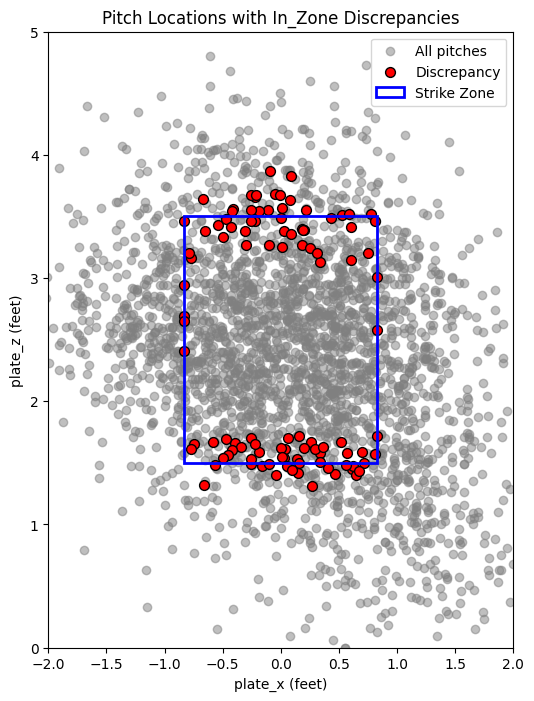

In [5]:
# Plotting the pitch data. Defining the strike zone.

# Highlighting pitches where "In_Zone_Our_Calc" is not equal to "In_Zone"
# Can be wrong in 2 ways: In_Zone = Strike & In_Zone_Our_Calc = Ball or In_Zone = Ball & In_Zone_Our_Calc = Strike

# Create a new DataFrame with rows where "In_Zone_Our_Calc" is not equal to "In_Zone"
df_in_zone_discrepancies = df_statcast[df_statcast['In_Zone_Our_Calc'] != df_statcast['In_Zone']]

# Plot the pitches with discrepancies between "In_Zone_Our_Calc" and "In_Zone"
fig, ax = plt.subplots(figsize=(6, 8))

# Plot all pitches as background (optional, for context)
ax.scatter(df_statcast['plate_x'], df_statcast['plate_z'], color='gray', alpha=0.5, label='All pitches')

# Plot pitches where "In_Zone_Our_Calc" != "In_Zone"
ax.scatter(
    df_in_zone_discrepancies['plate_x'],
    df_in_zone_discrepancies['plate_z'],
    c='red', label='Discrepancy', edgecolor='k', s=50
)

# Draw the strike zone (Statcast convention: plate_x in [-0.83, 0.83] feet)
# For vertical, use a typical strike zone (e.g., 1.5 to 3.5 feet), or show a box for a sample batter
strike_zone_left = -0.83
strike_zone_right = 0.83
strike_zone_bottom = 1.5
strike_zone_top = 3.5

# Draw rectangle for the strike zone
rect = plt.Rectangle(
    (strike_zone_left, strike_zone_bottom),
    strike_zone_right - strike_zone_left,
    strike_zone_top - strike_zone_bottom,
    fill=False, color='blue', linewidth=2, label='Strike Zone'
)
ax.add_patch(rect)

ax.set_xlabel('plate_x (feet)')
ax.set_ylabel('plate_z (feet)')
ax.set_title('Pitch Locations with In_Zone Discrepancies')
ax.set_xlim(-2, 2)
ax.set_ylim(0, 5)
ax.legend()
plt.show()


In [ ]:
# Assessing how the values of In_Zone_Our_Calc and In_Zone compare.

print("\nComparison of In_Zone_Our_Calc with original In_Zone:")
comparison_df = pd.crosstab(df_statcast['In_Zone_Our_Calc'], df_statcast['In_Zone'])
print(comparison_df)


Comparison of In_Zone_Our_Calc with original In_Zone:
In_Zone              0     1
In_Zone_Our_Calc            
0                 1367    97
1                    7  1301


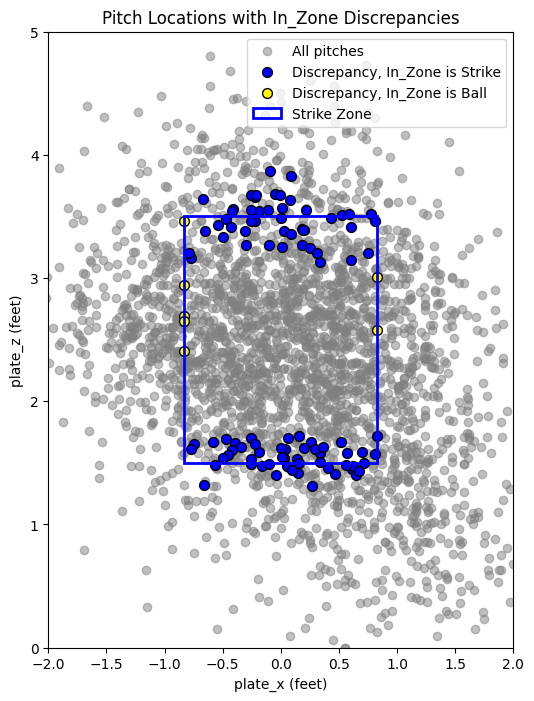

In [ ]:
# Plotting the pitch data. Defining the strike zone. This time, highliting where the discrepancy comes from. 


# Create a new DataFrame with rows where "In_Zone_Our_Calc" is not equal to "In_Zone"
df_in_zone_strikes = df_statcast[
    (df_statcast['In_Zone'] == 1) & (df_statcast['In_Zone'] != df_statcast['In_Zone_Our_Calc'])]

df_in_zone_balls = df_statcast[
    (df_statcast['In_Zone'] == 0) & (df_statcast['In_Zone'] != df_statcast['In_Zone_Our_Calc'])]

import matplotlib.pyplot as plt

# Plot the pitches with discrepancies between "In_Zone_Our_Calc" and "In_Zone"
fig, ax = plt.subplots(figsize=(6, 8))

# Plot all pitches as background (optional, for context)
ax.scatter(df_statcast['plate_x'], df_statcast['plate_z'], color='gray', alpha=0.5, label='All pitches')

# Plot pitches where "In_Zone_Our_Calc" != "In_Zone", but In_Zone is 1
ax.scatter(
    df_in_zone_strikes['plate_x'],
    df_in_zone_strikes['plate_z'],
    c='blue', label='Discrepancy, In_Zone is Strike', edgecolor='k', s=50
)

# Plot pitches where "In_Zone_Our_Calc" != "In_Zone", but In_Zone is 0
ax.scatter(
    df_in_zone_balls['plate_x'],
    df_in_zone_balls['plate_z'],
    c='yellow', label='Discrepancy, In_Zone is Ball', edgecolor='k', s=50
)

# Draw the strike zone (Statcast convention: plate_x in [-0.83, 0.83] feet)
# For vertical, use a typical strike zone (e.g., 1.5 to 3.5 feet), or show a box for a sample batter
strike_zone_left = -0.83
strike_zone_right = 0.83
strike_zone_bottom = 1.5
strike_zone_top = 3.5

# Draw rectangle for the strike zone
rect = plt.Rectangle(
    (strike_zone_left, strike_zone_bottom),
    strike_zone_right - strike_zone_left,
    strike_zone_top - strike_zone_bottom,
    fill=False, color='blue', linewidth=2, label='Strike Zone'
)
ax.add_patch(rect)

ax.set_xlabel('plate_x (feet)')
ax.set_ylabel('plate_z (feet)')
ax.set_title('Pitch Locations with In_Zone Discrepancies')
ax.set_xlim(-2, 2)
ax.set_ylim(0, 5)
ax.legend()
plt.show()

### We see that discrepancies where In_Zone, the 'strike' values from Statcast, are strikes, but our value of In_Zone_Our_Calc are balls, happen along upper and lower bounds of the strike zones. This is likely due to this part of the strike zone being variable depending on the height of the batter, which was not factored into defining strikes. 

### We see that discrepancies where In_Zone = Ball & In_Zone_Our_Calc = Strike occur on the left-right edges of the plate, which is likely just due to the definition of our strike zone width.  

Total Error Rate: 3.752%
Error Rate (Called Ball but Calculated Strike): 0.253%
Error Rate (Called Strike but Calculated Ball): 3.499%


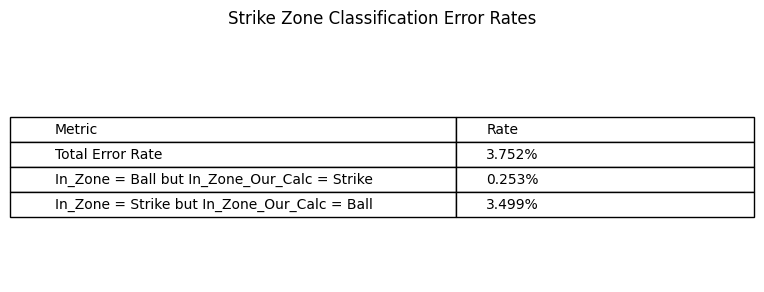

In [ ]:
# Error Rates between In_Zone and In_Zone_Our_Calc


# Calculate total number of pitches
total_pitches = len(df_statcast)

# Calculate total discrepancies
total_discrepancies = len(df_in_zone_balls) + len(df_in_zone_strikes)

# Calculate error rates
error_rate_total = total_discrepancies / total_pitches
error_rate_balls = len(df_in_zone_balls) / total_pitches  
error_rate_strikes = len(df_in_zone_strikes) / total_pitches

print(f"Total Error Rate: {error_rate_total:.3%}")
print(f"Error Rate (Called Ball but Calculated Strike): {error_rate_balls:.3%}")
print(f"Error Rate (Called Strike but Calculated Ball): {error_rate_strikes:.3%}")

# Create a table to visualize error rates
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

# Define table data
table_data = [
    ['Metric', 'Rate'],
    ['Total Error Rate', f'{error_rate_total:.3%}'],
    ['In_Zone = Ball but In_Zone_Our_Calc = Strike', f'{error_rate_balls:.3%}'],
    ['In_Zone = Strike but In_Zone_Our_Calc = Ball', f'{error_rate_strikes:.3%}']
]

# Create and customize table
table = ax.table(cellText=table_data, 
                 loc='center',
                 cellLoc='left',
                 colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Add title
plt.title('Strike Zone Classification Error Rates', pad=20)
plt.show()




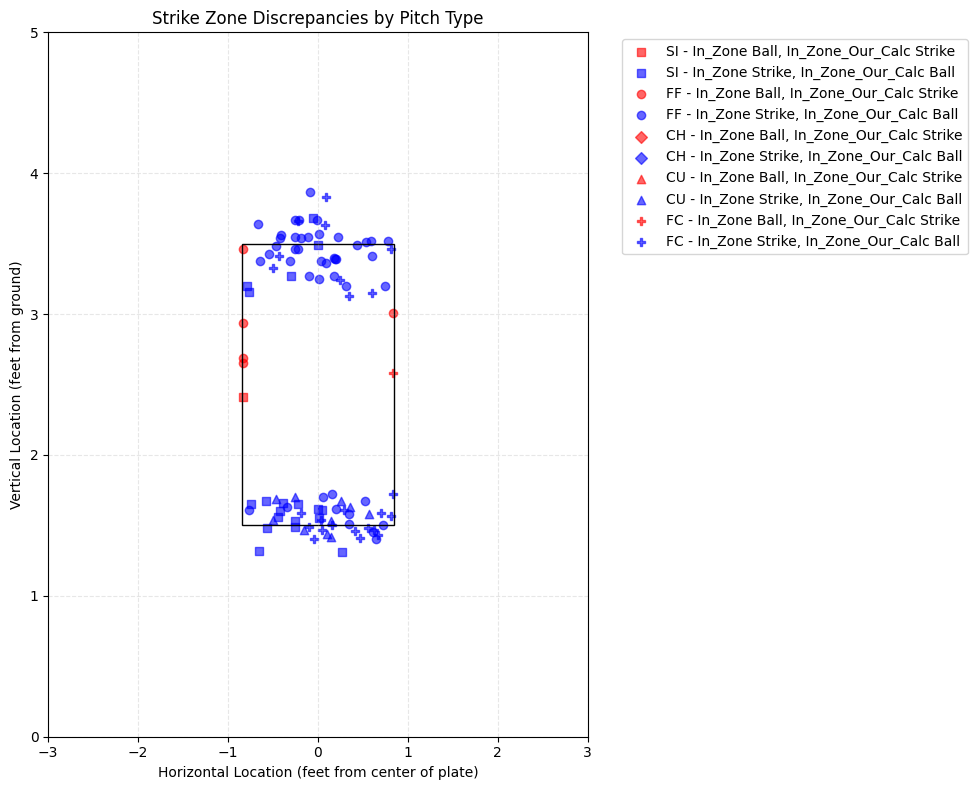

In [ ]:
# Looking at the discrepancies between In_Zone and In_Zone_Our_Calc by pitch type. 

# Create scatter plot
plt.figure(figsize=(10, 8))

# Define marker styles for different pitch types
marker_styles = {
    'FF': 'o',  # Four-seam fastball
    'SI': 's',  # Sinker
    'CU': '^',  # Curveball
    'CH': 'D',  # Changeup
    'SL': 'v',  # Slider
    'FC': 'P',  # Cutter
    'FS': '*',  # Split-finger
    'FT': 'h',  # Two-seam fastball
    'KC': 'X'   # Knuckle curve
}

# Plot each pitch type separately for correct legend
for pitch_type in df_statcast['pitch_type'].unique():
    # Plot balls called strikes (In_Zone = 0, In_Zone_Our_Calc = 1)
    mask_balls = (df_statcast['pitch_type'] == pitch_type) & \
                 (df_statcast['In_Zone'] == 0) & \
                 (df_statcast['In_Zone_Our_Calc'] == 1)
    plt.scatter(df_statcast[mask_balls]['plate_x'], 
               df_statcast[mask_balls]['plate_z'],
               color='red', 
               marker=marker_styles.get(pitch_type, 'o'),
               label=f'{pitch_type} - In_Zone Ball, In_Zone_Our_Calc Strike',
               alpha=0.6)
    
    # Plot strikes called balls (In_Zone = 1, In_Zone_Our_Calc = 0)
    mask_strikes = (df_statcast['pitch_type'] == pitch_type) & \
                   (df_statcast['In_Zone'] == 1) & \
                   (df_statcast['In_Zone_Our_Calc'] == 0)
    plt.scatter(df_statcast[mask_strikes]['plate_x'], 
               df_statcast[mask_strikes]['plate_z'],
               color='blue',
               marker=marker_styles.get(pitch_type, 'o'),
               label=f'{pitch_type} - In_Zone Strike, In_Zone_Our_Calc Ball',
               alpha=0.6)

# Draw strike zone
strike_zone = plt.Rectangle((-0.85, 1.5), 1.7, 2.0, fill=False, color='black')
plt.gca().add_patch(strike_zone)

# Set axis labels and title
plt.xlabel('Horizontal Location (feet from center of plate)')
plt.ylabel('Vertical Location (feet from ground)')
plt.title('Strike Zone Discrepancies by Pitch Type')

# Adjust plot limits
plt.xlim(-3, 3)
plt.ylim(0, 5)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3)

# Adjust legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent legend cutoff
plt.tight_layout()

plt.show()



In [10]:
df_view = df_statcast[['plate_x', 'plate_z', 'In_Zone', 'In_Zone_Our_Calc']]
df_view.head(20)

,plate_x,plate_z,In_Zone,In_Zone_Our_Calc
0,-0.92,2.52,0,0
1,-0.05,3.27,1,1
2,-1.12,2.33,0,0
3,-1.35,2.78,0,0
4,-2.20,3.45,0,0
5,-2.05,2.27,0,0
6,0.08,2.06,1,1
7,-1.87,1.83,0,0
8,-1.65,2.29,0,0
9,0.01,2.55,1,1


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ranges for pitches In_Zone & In_Zone_Our_Calc as balls:
plate_x range: -2.55 to 2.64
plate_z range: -0.82 to 4.80

Ranges for pitches In_Zone & In_Zone_Our_Calc as strikes:
plate_x range: -0.83 to 0.82
plate_z range: 1.41 to 3.70

Ranges for pitches In_Zone = Ball & In_Zone_Our_Calc = Strike:
plate_x range: -0.83 to 0.83
plate_z range: 2.41 to 3.46

Ranges for pitches In_Zone = Strike & In_Zone_Our_Calc = Ball:
plate_x range: -0.79 to 0.83
plate_z range: 1.31 to 3.87

Ranges for pitches In_Zone = Strike:
plate_x range: -0.83 to 0.83
plate_z range: 1.31 to 3.87

Ranges for pitches In_Zone = Ball:
plate_x range: -2.55 to 2.64
plate_z range: -0.82 to 4.80

Ranges for pitches In_Zone = Ball (Left side of the plate):
plate_x range: -2.55 to -0.01
plate_z range: 0.15 to 4.80

Ranges for pitches In_Zone = Ball (Right side of the plate):
plate_x range: 0.01 to 2.64
plate_z range: -0.82 to 4.73



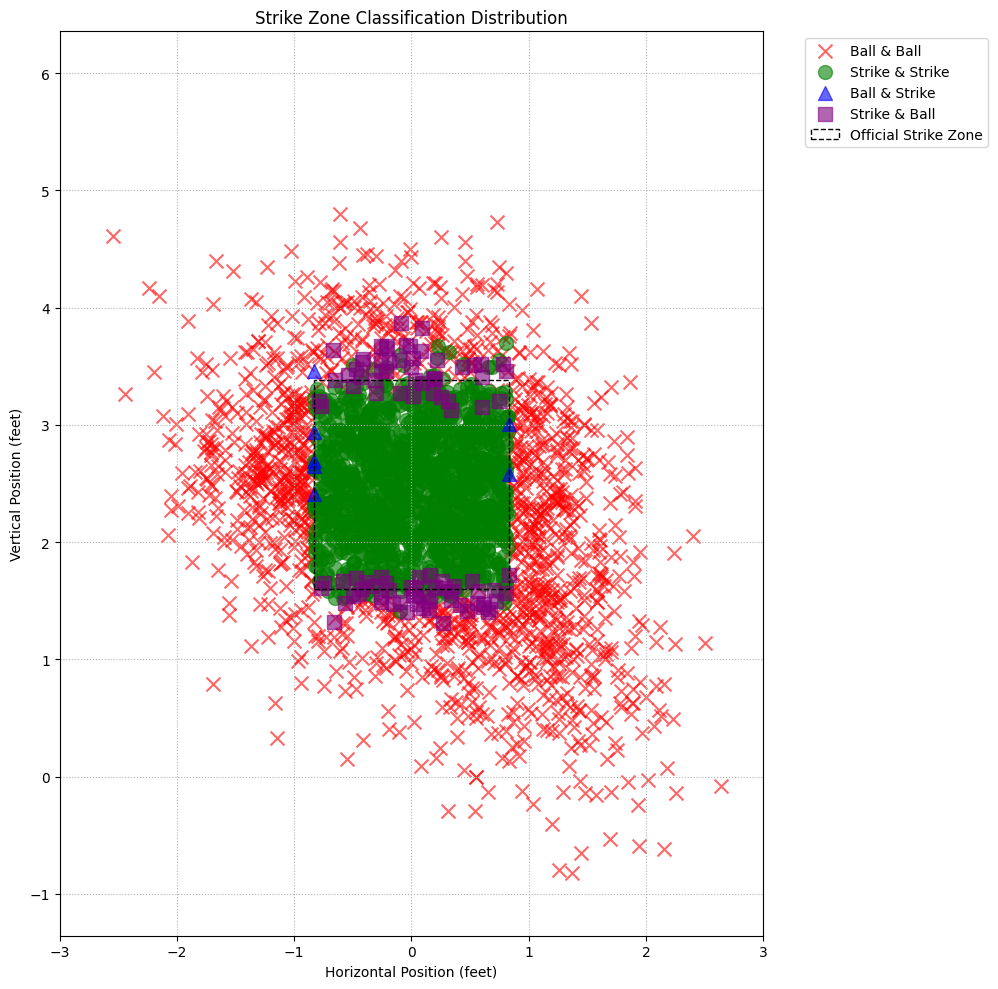

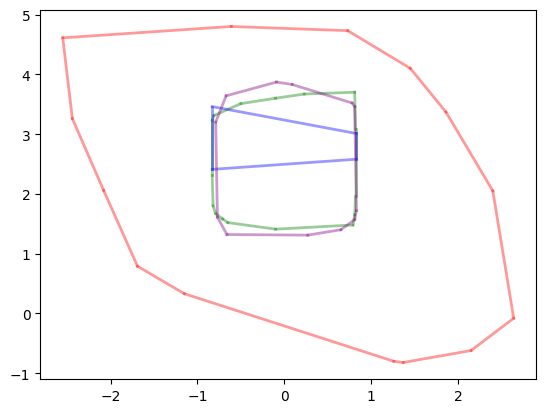

In [ ]:
# Looking at ranges of locations for each combination of In_Zone and In_Zone_Our_Calc



# Create dataframes for each combination of In_Zone and In_Zone_Our_Calc
df_iz_ball_izoc_ball = df_statcast[(df_statcast['In_Zone'] == 0) & (df_statcast['In_Zone_Our_Calc'] == 0)]
df_iz_strike_izoc_strike = df_statcast[(df_statcast['In_Zone'] == 1) & (df_statcast['In_Zone_Our_Calc'] == 1)]
df_iz_ball_izoc_strike = df_statcast[(df_statcast['In_Zone'] == 0) & (df_statcast['In_Zone_Our_Calc'] == 1)]
df_iz_strike_izoc_ball = df_statcast[(df_statcast['In_Zone'] == 1) & (df_statcast['In_Zone_Our_Calc'] == 0)]
df_iz_ball = df_statcast[df_statcast['In_Zone'] == 0]
df_iz_strike = df_statcast[df_statcast['In_Zone'] == 1]

# Get values of df_iz_ball where plate_x is less than 0
df_iz_ball_left = df_iz_ball[df_iz_ball['plate_x'] < 0]

# Get values of df_iz_ball where plate_x is greater than 0
df_iz_ball_right = df_iz_ball[df_iz_ball['plate_x'] > 0]


# Get ranges for each dataframe
print("Ranges for pitches In_Zone & In_Zone_Our_Calc as balls:")
print(f"plate_x range: {df_iz_ball_izoc_ball['plate_x'].min():.2f} to {df_iz_ball_izoc_ball['plate_x'].max():.2f}")
print(f"plate_z range: {df_iz_ball_izoc_ball['plate_z'].min():.2f} to {df_iz_ball_izoc_ball['plate_z'].max():.2f}\n")

print("Ranges for pitches In_Zone & In_Zone_Our_Calc as strikes:")
print(f"plate_x range: {df_iz_strike_izoc_strike['plate_x'].min():.2f} to {df_iz_strike_izoc_strike['plate_x'].max():.2f}")
print(f"plate_z range: {df_iz_strike_izoc_strike['plate_z'].min():.2f} to {df_iz_strike_izoc_strike['plate_z'].max():.2f}\n")

print("Ranges for pitches In_Zone = Ball & In_Zone_Our_Calc = Strike:")
print(f"plate_x range: {df_iz_ball_izoc_strike['plate_x'].min():.2f} to {df_iz_ball_izoc_strike['plate_x'].max():.2f}")
print(f"plate_z range: {df_iz_ball_izoc_strike['plate_z'].min():.2f} to {df_iz_ball_izoc_strike['plate_z'].max():.2f}\n")

print("Ranges for pitches In_Zone = Strike & In_Zone_Our_Calc = Ball:")
print(f"plate_x range: {df_iz_strike_izoc_ball['plate_x'].min():.2f} to {df_iz_strike_izoc_ball['plate_x'].max():.2f}")
print(f"plate_z range: {df_iz_strike_izoc_ball['plate_z'].min():.2f} to {df_iz_strike_izoc_ball['plate_z'].max():.2f}\n")

print("Ranges for pitches In_Zone = Strike:")
print(f"plate_x range: {df_iz_strike['plate_x'].min():.2f} to {df_iz_strike['plate_x'].max():.2f}")
print(f"plate_z range: {df_iz_strike['plate_z'].min():.2f} to {df_iz_strike['plate_z'].max():.2f}\n")

print("Ranges for pitches In_Zone = Ball:")
print(f"plate_x range: {df_iz_ball['plate_x'].min():.2f} to {df_iz_ball['plate_x'].max():.2f}")
print(f"plate_z range: {df_iz_ball['plate_z'].min():.2f} to {df_iz_ball['plate_z'].max():.2f}\n")

print("Ranges for pitches In_Zone = Ball (Left side of the plate):")
print(f"plate_x range: {df_iz_ball_left['plate_x'].min():.2f} to {df_iz_ball_left['plate_x'].max():.2f}")
print(f"plate_z range: {df_iz_ball_left['plate_z'].min():.2f} to {df_iz_ball_left['plate_z'].max():.2f}\n")


print("Ranges for pitches In_Zone = Ball (Right side of the plate):")
print(f"plate_x range: {df_iz_ball_right['plate_x'].min():.2f} to {df_iz_ball_right['plate_x'].max():.2f}")
print(f"plate_z range: {df_iz_ball_right['plate_z'].min():.2f} to {df_iz_ball_right['plate_z'].max():.2f}\n")
# Create a figure and axis
plt.figure(figsize=(10, 10))
ax = plt.gca()

# Plot each zone as a scatter plot with different markers and colors
# Ball & Ball
plt.scatter(df_iz_ball_izoc_ball['plate_x'], df_iz_ball_izoc_ball['plate_z'], 
           color='red', marker='x', s=100, label='Ball & Ball', alpha=0.6)

# Strike & Strike
plt.scatter(df_iz_strike_izoc_strike['plate_x'], df_iz_strike_izoc_strike['plate_z'],
           color='green', marker='o', s=100, label='Strike & Strike', alpha=0.6)

# Ball & Strike
plt.scatter(df_iz_ball_izoc_strike['plate_x'], df_iz_ball_izoc_strike['plate_z'],
           color='blue', marker='^', s=100, label='Ball & Strike', alpha=0.6)

# Strike & Ball  
plt.scatter(df_iz_strike_izoc_ball['plate_x'], df_iz_strike_izoc_ball['plate_z'],
           color='purple', marker='s', s=100, label='Strike & Ball', alpha=0.6)

# Add official strike zone boundaries (average)
sz_left, sz_right = -0.83, 0.83
sz_bottom = df_statcast['sz_bot'].mean()
sz_top = df_statcast['sz_top'].mean()

# Plot strike zone rectangle
ax.add_patch(plt.Rectangle((sz_left, sz_bottom),
                          sz_right - sz_left,
                          sz_top - sz_bottom,
                          fill=False, color='black', linestyle='--',
                          label='Official Strike Zone'))

# Set axis labels and title
plt.xlabel('Horizontal Position (feet)')
plt.ylabel('Vertical Position (feet)')
plt.title('Strike Zone Classification Distribution')

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Set equal aspect ratio
plt.axis('equal')

# Show grid
plt.grid(True, linestyle=':')

# Set axis limits with some padding
plt.xlim(-3, 3)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()
# Add borders around each classification group
for group, style in [
    (df_iz_ball_izoc_ball, {'color': 'red', 'linestyle': '-'}),
    (df_iz_strike_izoc_strike, {'color': 'green', 'linestyle': '-'}), 
    (df_iz_ball_izoc_strike, {'color': 'blue', 'linestyle': '-'}),
    (df_iz_strike_izoc_ball, {'color': 'purple', 'linestyle': '-'})
]:
    if not group.empty:
        # Create convex hull around points
        points = group[['plate_x', 'plate_z']].values
        if len(points) >= 3:  # Need at least 3 points for convex hull
            from scipy.spatial import ConvexHull
            hull = ConvexHull(points)
            
            # Plot the convex hull boundary
            for simplex in hull.simplices:
                plt.plot(points[simplex, 0], points[simplex, 1], 
                        **style, alpha=0.4, linewidth=2)



In [ ]:
### Goal --> Standardize the strike zone to a fixed size, so that we can compare the distribution of pitches in the strike zone to the distribution of pitches in the strike zone. 

# Make a strike zone that is 'typical' of the Strike Zone

# Scale that from -100 to 100 (left right) & then 0 to 100 (up down)

# Then change the pitch locations to this standardized strike zone. 


In [120]:
# Standardizing the strike zone to a fixed size, so that we can compare the distribution of pitches in the strike zone to the distribution of pitches in the strike zone. 

# This time, we'll use the strike zone height to standardize the strike zone. 

df_statcast_std = df_statcast.copy()

# Calculate strike zone height for each pitch
df_statcast_std['sz_height'] = df_statcast_std['sz_top'] - df_statcast_std['sz_bot']

# Calculate relative position of plate_z between sz_bot (-100) and sz_top (100)
df_statcast_std['plate_z_scaled'] = (
    (df_statcast_std['plate_z'] - df_statcast_std['sz_bot']) / df_statcast_std['sz_height'] * 200 - 100
)

# Standardize plate_x to -100 to 100 scale
# Strike zone width is approximately 17 inches (-8.5 to 8.5 inches)
df_statcast_std['plate_x_scaled'] = (df_statcast_std['plate_x'] * 12) / 8.5 * 100

df_statcast_std['plate_x_scaled'] = ((100 / 0.83) *df_statcast_std['plate_x'])

print(df_statcast_std[['plate_x', 'plate_x_scaled', 'plate_z', 'plate_z_scaled', 'sz_top', 'sz_bot']].head(25))


    plate_x  plate_x_scaled  plate_z  plate_z_scaled  sz_top  sz_bot
0     -0.92     -110.843373     2.52        0.000000    3.39    1.65
1     -0.05       -6.024096     3.27       86.206897    3.39    1.65
2     -1.12     -134.939759     2.33      -36.898396    3.61    1.74
3     -1.35     -162.650602     2.78       11.229947    3.61    1.74
4     -2.20     -265.060241     3.45       88.950276    3.55    1.74
5     -2.05     -246.987952     2.27      -43.315508    3.61    1.74
6      0.08        9.638554     2.06      -32.926829    3.15    1.51
7     -1.87     -225.301205     1.83      -62.790698    3.23    1.51
8     -1.65     -198.795181     2.29      -10.857143    3.26    1.51
9      0.01        1.204819     2.55       -6.214689    3.49    1.72
10     1.07      128.915663     1.66     -106.349206    3.61    1.72
11     1.81      218.072289     1.58     -119.251337    3.63    1.76
12    -0.21      -25.301205     3.06       39.037433    3.63    1.76
13    -0.06       -7.228916     2.

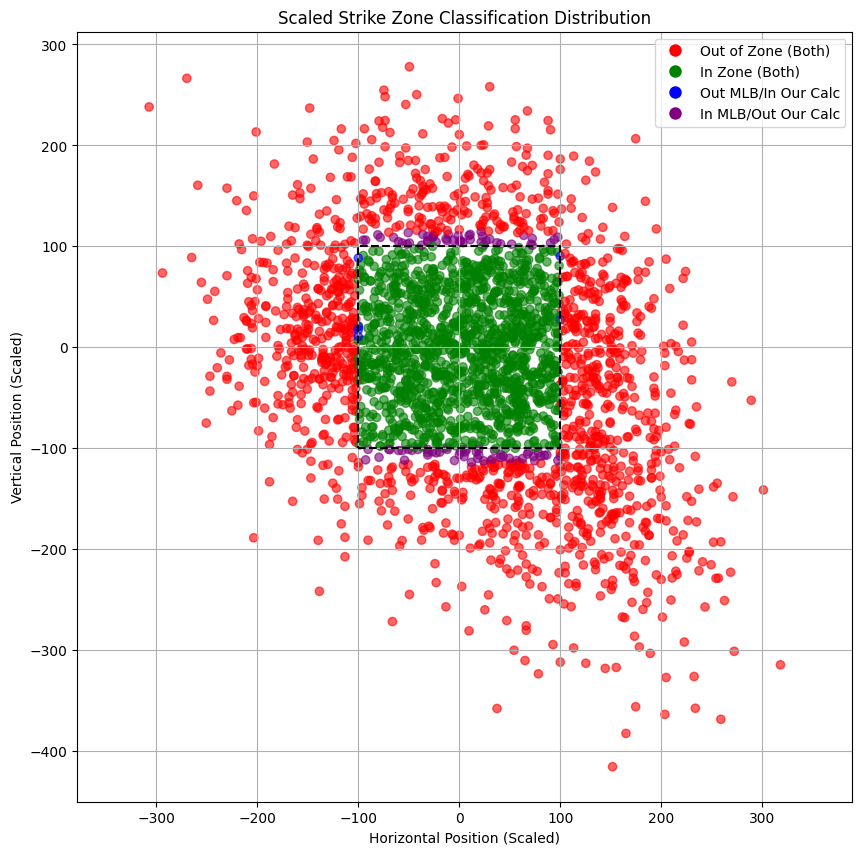

In [123]:
# Create scatter plot of scaled pitch locations
plt.figure(figsize=(10,10))

# Plot points with scaled coordinates
colors = ['red' if not iz and not izoc else 
          'green' if iz and izoc else 
          'blue' if not iz and izoc else
          'purple' if iz and not izoc else 'gray'
          for iz, izoc in zip(df_statcast_std['In_Zone'], df_statcast_std['In_Zone_Our_Calc'])]

plt.scatter(df_statcast_std['plate_x_scaled'], df_statcast_std['plate_z_scaled'], c=colors, alpha=0.6)

# Draw standardized strike zone (-100 to 100 for both dimensions)
plt.plot([-100, 100, 100, -100, -100], [-100, -100, 100, 100, -100], 'k--', label='Standardized Strike Zone')

# Set axis labels and title
plt.xlabel('Horizontal Position (Scaled)')
plt.ylabel('Vertical Position (Scaled)') 
plt.title('Scaled Strike Zone Classification Distribution')

# Add legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Out of Zone (Both)', markersize=10),
                  plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='In Zone (Both)', markersize=10),
                  plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Out MLB/In Our Calc', markersize=10),
                  plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', label='In MLB/Out Our Calc', markersize=10)]
plt.legend(handles=legend_elements)

plt.grid(True)
plt.axis('equal')
plt.show()



# I want to further investigate the differences between the MLB and our calculated strike zone.
# I have a feeling that the differences are due to the movement of the pitches.


In [ ]:
# Seperating the pitches into left and right boundary pitches that are one side of the strike zone.

# Find pitches at the horizontal boundaries
boundary_pitches_left = df_statcast_std[
    (df_statcast_std['plate_x_scaled'] == -100.0)
]

boundary_pitches_right = df_statcast_std[
    (df_statcast_std['plate_x_scaled'] == 100.0)
]

# Create comparison table for left boundary pitches
print("\nLeft Boundary Pitch Classification Comparison:")
comparison_table = pd.crosstab(boundary_pitches_left['In_Zone'], 
                             boundary_pitches_left['In_Zone_Our_Calc'],
                             margins=True)
print("\nRows: MLB In_Zone, Columns: Our In_Zone_Our_Calc")
print(comparison_table)

# Calculate agreement percentage
total_pitches = len(boundary_pitches_left)
matching_calls = sum(boundary_pitches_left['In_Zone'] == boundary_pitches_left['In_Zone_Our_Calc'])
agreement_pct = (matching_calls / total_pitches * 100) if total_pitches > 0 else 0

print(f"\nAgreement Rate: {agreement_pct:.1f}% ({matching_calls} out of {total_pitches} pitches)")


# Create comparison table for left boundary pitches
print("\nRight Boundary Pitch Classification Comparison:")
comparison_table = pd.crosstab(boundary_pitches_right['In_Zone'], 
                             boundary_pitches_right['In_Zone_Our_Calc'],
                             margins=True)
print("\nRows: MLB In_Zone, Columns: Our In_Zone_Our_Calc")
print(comparison_table)

# Calculate agreement percentage
total_pitches = len(boundary_pitches_right)
matching_calls = sum(boundary_pitches_right['In_Zone'] == boundary_pitches_right['In_Zone_Our_Calc'])
agreement_pct = (matching_calls / total_pitches * 100) if total_pitches > 0 else 0

print(f"\nAgreement Rate: {agreement_pct:.1f}% ({matching_calls} out of {total_pitches} pitches)")



Left Boundary Pitch Classification Comparison:

Rows: MLB In_Zone, Columns: Our In_Zone_Our_Calc
In_Zone_Our_Calc  0   1  All
In_Zone                     
0                 2   5    7
1                 0   5    5
All               2  10   12

Agreement Rate: 58.3% (7 out of 12 pitches)

Right Boundary Pitch Classification Comparison:

Rows: MLB In_Zone, Columns: Our In_Zone_Our_Calc
In_Zone_Our_Calc  0  1  All
In_Zone                    
0                 6  2    8
1                 1  0    1
All               7  2    9

Agreement Rate: 66.7% (6 out of 9 pitches)


# We see low amounts of pitches that are exactly on the strike zone, so I went to pull additional data from previous seasons as well. 

In [ ]:
# Retrieve data from 2020-2024
# Apply the same process to the data for the other data. 

years = [2020, 2021, 2022, 2023, 2024]
wheeler_data_list = []

for year in years:
    comprehensive_data = get_comprehensive_pitcher_data(554430, year)
    df_year = comprehensive_data['statcast_data']
    wheeler_data_list.append(df_year)

# Combine all years of data
wheeler_all_years = pd.concat(wheeler_data_list, ignore_index=True)

# Standardize the data (assuming this matches previous standardization)
wheeler_data = wheeler_all_years.copy()

wheeler_data['In_Zone_Our_Calc'] = wheeler_data.apply(is_in_zone_our_calc, axis=1)
wheeler_data['In_Zone'] = wheeler_data['zone'].apply(assign_in_zone_from_zone)


#Calculate strike zone height for each pitch
wheeler_data['sz_height'] = wheeler_data['sz_top'] - wheeler_data['sz_bot']

# Calculate relative position of plate_z between sz_bot (-100) and sz_top (100)
wheeler_data['plate_z_scaled'] = (
    (wheeler_data['plate_z'] - wheeler_data['sz_bot']) / wheeler_data['sz_height'] * 200 - 100
)

# Standardize plate_x to -100 to 100 scale
# Strike zone width is approximately 17 inches (-8.5 to 8.5 inches)
wheeler_data['plate_x_scaled'] = (wheeler_data['plate_x'] * 12) / 8.5 * 100

wheeler_data['plate_x_scaled'] = ((100 / 0.83) *wheeler_data['plate_x'])


# Find pitches at the horizontal boundaries for Wheeler
wheeler_boundary_left = wheeler_data[
    (wheeler_data['plate_x_scaled'] == -100.0)
]

wheeler_boundary_right = wheeler_data[
    (wheeler_data['plate_x_scaled'] == 100.0)
]


Fetching comprehensive data for pitcher ID 554430 in the 2020 season...

Fetching Statcast data for pitcher ID 554430 in 2020...
Gathering Player Data
Successfully retrieved Statcast data for pitcher ID 554430

Fetching comprehensive data for pitcher ID 554430 in the 2021 season...

Fetching Statcast data for pitcher ID 554430 in 2021...
Gathering Player Data
Successfully retrieved Statcast data for pitcher ID 554430

Fetching comprehensive data for pitcher ID 554430 in the 2022 season...

Fetching Statcast data for pitcher ID 554430 in 2022...
Gathering Player Data
Successfully retrieved Statcast data for pitcher ID 554430

Fetching comprehensive data for pitcher ID 554430 in the 2023 season...

Fetching Statcast data for pitcher ID 554430 in 2023...
Gathering Player Data
Successfully retrieved Statcast data for pitcher ID 554430

Fetching comprehensive data for pitcher ID 554430 in the 2024 season...

Fetching Statcast data for pitcher ID 554430 in 2024...
Gathering Player Data
Succ

In [155]:
# Comparing the strike zone for Wheeler between the MLB and our calculated strike zone.

# Create comparison table for left boundary pitches
print("\nWheeler Left Boundary Pitch Classification Comparison (2020-2024):")
comparison_table = pd.crosstab(wheeler_boundary_left['In_Zone'], 
                             wheeler_boundary_left['In_Zone_Our_Calc'],
                             margins=True)
print("\nRows: MLB In_Zone, Columns: Our In_Zone_Our_Calc")
print(comparison_table)

# Calculate agreement percentage
total_pitches = len(wheeler_boundary_left)
matching_calls = sum(wheeler_boundary_left['In_Zone'] == wheeler_boundary_left['In_Zone_Our_Calc'])
agreement_pct = (matching_calls / total_pitches * 100) if total_pitches > 0 else 0

print(f"\nAgreement Rate: {agreement_pct:.1f}% ({matching_calls} out of {total_pitches} pitches)")

# Create comparison table for right boundary pitches
print("\nWheeler Right Boundary Pitch Classification Comparison (2020-2024):")
comparison_table = pd.crosstab(wheeler_boundary_right['In_Zone'], 
                             wheeler_boundary_right['In_Zone_Our_Calc'],
                             margins=True)
print("\nRows: MLB In_Zone, Columns: Our In_Zone_Our_Calc")
print(comparison_table)

# Calculate agreement percentage
total_pitches = len(wheeler_boundary_right)
matching_calls = sum(wheeler_boundary_right['In_Zone'] == wheeler_boundary_right['In_Zone_Our_Calc'])
agreement_pct = (matching_calls / total_pitches * 100) if total_pitches > 0 else 0

print(f"\nAgreement Rate: {agreement_pct:.1f}% ({matching_calls} out of {total_pitches} pitches)")




Wheeler Left Boundary Pitch Classification Comparison (2020-2024):

Rows: MLB In_Zone, Columns: Our In_Zone_Our_Calc
In_Zone_Our_Calc   0   1  All
In_Zone                      
0.0               12  27   39
1.0                0  14   14
All               12  41   53

Agreement Rate: 49.1% (26 out of 53 pitches)

Wheeler Right Boundary Pitch Classification Comparison (2020-2024):

Rows: MLB In_Zone, Columns: Our In_Zone_Our_Calc
In_Zone_Our_Calc   0   1  All
In_Zone                      
0.0               19  13   32
1.0                4  13   17
All               23  26   49

Agreement Rate: 65.3% (32 out of 49 pitches)


In [ ]:
# Looking at the differences on each side of the strike zone from a percentage standpoint. 

# Create comparison table for left boundary pitches with percentages
print("\nWheeler Left Boundary Pitch Classification Comparison (2020-2024):")
comparison_table = pd.crosstab(wheeler_boundary_left['In_Zone'], 
                             wheeler_boundary_left['In_Zone_Our_Calc'],
                             normalize='all') * 100
print("\nRows: MLB In_Zone, Columns: Our In_Zone_Our_Calc (percentages)")
print(comparison_table.round(1))

# Calculate agreement percentage for left boundary
total_pitches = len(wheeler_boundary_left)
matching_calls = sum(wheeler_boundary_left['In_Zone'] == wheeler_boundary_left['In_Zone_Our_Calc'])
agreement_pct = (matching_calls / total_pitches * 100) if total_pitches > 0 else 0

print(f"\nAgreement Rate: {agreement_pct:.1f}% ({matching_calls} out of {total_pitches} pitches)")

# Create comparison table for right boundary pitches with percentages
print("\nWheeler Right Boundary Pitch Classification Comparison (2020-2024):")
comparison_table = pd.crosstab(wheeler_boundary_right['In_Zone'], 
                             wheeler_boundary_right['In_Zone_Our_Calc'],
                             normalize='all') * 100
print("\nRows: MLB In_Zone, Columns: Our In_Zone_Our_Calc (percentages)")
print(comparison_table.round(1))

# Calculate agreement percentage for right boundary
total_pitches = len(wheeler_boundary_right)
matching_calls = sum(wheeler_boundary_right['In_Zone'] == wheeler_boundary_right['In_Zone_Our_Calc'])
agreement_pct = (matching_calls / total_pitches * 100) if total_pitches > 0 else 0

print(f"\nAgreement Rate: {agreement_pct:.1f}% ({matching_calls} out of {total_pitches} pitches)")



Wheeler Left Boundary Pitch Classification Comparison (2020-2024):

Rows: MLB In_Zone, Columns: Our In_Zone_Our_Calc (percentages)
In_Zone_Our_Calc     0     1
In_Zone                     
0.0               22.6  50.9
1.0                0.0  26.4

Agreement Rate: 49.1% (26 out of 53 pitches)

Wheeler Right Boundary Pitch Classification Comparison (2020-2024):

Rows: MLB In_Zone, Columns: Our In_Zone_Our_Calc (percentages)
In_Zone_Our_Calc     0     1
In_Zone                     
0.0               38.8  26.5
1.0                8.2  26.5

Agreement Rate: 65.3% (32 out of 49 pitches)


In [ ]:
# Looking at which pitches are causing discrepancies based on the side of the strike zone. 

# Get disagreement pitches for left boundary
disagreement_pitches = wheeler_boundary_left[wheeler_boundary_left['In_Zone'] != wheeler_boundary_left['In_Zone_Our_Calc']]

# Display pitch types for disagreements
print("\nPitch types for disagreements on left boundary:")
print(disagreement_pitches['pitch_name'].value_counts())

# Get disagreement pitches for right boundary
disagreement_pitches = wheeler_boundary_right[wheeler_boundary_right['In_Zone'] != wheeler_boundary_right['In_Zone_Our_Calc']]

# Display pitch types for disagreements
print("\nPitch types for disagreements on right boundary:")
print(disagreement_pitches['pitch_name'].value_counts())


Pitch types for disagreements on left boundary:
pitch_name
4-Seam Fastball    15
Sinker              8
Cutter              2
Changeup            1
Curveball           1
Name: count, dtype: int64

Pitch types for disagreements on right boundary:
pitch_name
Cutter             9
4-Seam Fastball    5
Curveball          1
Sweeper            1
Split-Finger       1
Name: count, dtype: int64


In [ ]:
# Defining the average movement of each pitch type. 

# Analyze pitch movement by pitch type
print("\nPitch Movement Analysis by Pitch Type:")
movement_analysis = wheeler_data.groupby('pitch_name').agg({
    'pfx_x': 'mean',  # Horizontal movement in feet
    'pfx_z': 'mean'   # Vertical movement in feet
}).round(2)

# Convert movement from feet to inches for easier interpretation
movement_analysis = movement_analysis * 12

print("\nAverage Movement by Pitch Type (in inches):")
print("Positive pfx_x = Movement toward RHH")
print("Positive pfx_z = Upward Movement")
print("\n", movement_analysis)

# Create lists of pitches based on horizontal movement direction
right_moving_pitches = movement_analysis[movement_analysis['pfx_x'] > 0].index.tolist()
left_moving_pitches = movement_analysis[movement_analysis['pfx_x'] < 0].index.tolist()

print("\nPitches that move right (toward RHH):")
print(right_moving_pitches)
print("\nPitches that move left (toward LHH):")
print(left_moving_pitches)



Pitch Movement Analysis by Pitch Type:

Average Movement by Pitch Type (in inches):
Positive pfx_x = Movement toward RHH
Positive pfx_z = Upward Movement

                  pfx_x  pfx_z
pitch_name                   
4-Seam Fastball  -7.92  15.36
Changeup        -13.44  10.56
Curveball         9.48 -10.44
Cutter            2.28   6.12
Sinker          -16.08   9.48
Slider           12.00   2.16
Split-Finger    -12.96   5.64
Sweeper          11.88   2.76

Pitches that move right (toward RHH):
['Curveball', 'Cutter', 'Slider', 'Sweeper']

Pitches that move left (toward LHH):
['4-Seam Fastball', 'Changeup', 'Sinker', 'Split-Finger']

Left boundary disagreements by movement direction:
Right-moving pitches:
pitch_name
Cutter       2
Curveball    1
Name: count, dtype: int64

Left-moving pitches:
pitch_name
4-Seam Fastball    15
Sinker              8
Changeup            1
Name: count, dtype: int64


In [ ]:
# Assigning pitch movement direction to each boundary discrepancy pitch.

# Get disagreement pitches for left boundary
disagreement_pitches_left = wheeler_boundary_left[wheeler_boundary_left['In_Zone'] != wheeler_boundary_left['In_Zone_Our_Calc']]

# Count pitches by movement direction
print("\nLeft boundary disagreements by movement direction:\n")
print("Right-moving pitches:")
print(disagreement_pitches_left[disagreement_pitches_left['pitch_name'].isin(right_moving_pitches)]['pitch_name'].value_counts())
print("\nLeft-moving pitches:") 
print(disagreement_pitches_left[disagreement_pitches_left['pitch_name'].isin(left_moving_pitches)]['pitch_name'].value_counts())

# Get disagreement pitches for left boundary
disagreement_pitches_right = wheeler_boundary_right[wheeler_boundary_right['In_Zone'] != wheeler_boundary_right['In_Zone_Our_Calc']]

# Count pitches by movement direction
print("\n\nRight boundary disagreements by movement direction:\n")
print("Right-moving pitches:")
print(disagreement_pitches_right[disagreement_pitches_right['pitch_name'].isin(right_moving_pitches)]['pitch_name'].value_counts())
print("\nLeft-moving pitches:") 
print(disagreement_pitches_right[disagreement_pitches_right['pitch_name'].isin(left_moving_pitches)]['pitch_name'].value_counts())


Left boundary disagreements by movement direction:

Right-moving pitches:
pitch_name
Cutter       2
Curveball    1
Name: count, dtype: int64

Left-moving pitches:
pitch_name
4-Seam Fastball    15
Sinker              8
Changeup            1
Name: count, dtype: int64


Right boundary disagreements by movement direction:

Right-moving pitches:
pitch_name
Cutter       9
Curveball    1
Sweeper      1
Name: count, dtype: int64

Left-moving pitches:
pitch_name
4-Seam Fastball    5
Split-Finger       1
Name: count, dtype: int64


# We see that there for pitches that have a discrepancy between MLB labeled strikes & strikes defined by the strike zone using our calculations. 

# When we look at pitches that have a conflicting definition on the left-side of the plate, we see that 92.3% (24/26) of pitches are left-moving pitches. 

# Similarly, when we look at pitches that have a conflicting definition on the right-side of the plate, we see that 64.7% (11/17) of pitches are right-moving pitches. 

# This may certainly be due to the fact that Zach Wheeler throws more pitches that move out of the strike zone, as expected, but this may certainly be a reason for the differences in defining these pitches. 